In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer # จำเป็นต้อง import เพื่อเปิดใช้งาน IterativeImputer
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

In [2]:
# ==========================================
# ส่วนที่ 1: Methodology - Data Preparation & Missing Data Simulation
# (นำโค้ดนี้ไปวางใน Cell ถัดจากบรรทัด df = pd.read_csv(...) ของคุณ)
# ==========================================
# ตั้งค่า Style สำหรับกราฟ
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'sans-serif'

df = pd.read_csv('data/synthetic_personal_finance_dataset.csv')

print("--- เริ่มต้นกระบวนการ Methodology ---")

# สมมติว่าเราเลือกตัวแปร 'education_level' ซึ่งเป็น Categorical data ในการทดสอบ
target_col = 'education_level' 

# ตรวจสอบว่ามีคอลัมน์นี้หรือไม่ (ป้องกัน Error)
if target_col not in df.columns:
    # หากไม่มี ให้ดึงคอลัมน์ Categorical คอลัมน์แรกมาใช้แทน
    target_col = df.select_dtypes(include=['object']).columns[0]
    print(f"ไม่พบ {target_col} จึงเปลี่ยนไปใช้ตัวแปร: {target_col}")

print(f"ตัวแปรที่ใช้ทดสอบการเติมค่าสูญหาย: {target_col}")

# ฟังก์ชันสำหรับจำลองข้อมูลสูญหายแบบสุ่ม (MCAR - Missing Completely at Random)
def simulate_missing_data(data, column, missing_rate):
    df_simulated = data.copy()
    n_missing = int(len(data) * missing_rate)
    
    # สุ่ม index ที่จะทำให้ค่าหายไป
    np.random.seed(42) # ล็อก seed เพื่อให้ผลลัพธ์คงที่ในการทดลอง
    missing_indices = np.random.choice(data.index, n_missing, replace=False)
    
    df_simulated.loc[missing_indices, column] = np.nan
    return df_simulated, missing_indices

--- เริ่มต้นกระบวนการ Methodology ---
ตัวแปรที่ใช้ทดสอบการเติมค่าสูญหาย: education_level


In [4]:
# ==========================================
# ส่วนที่ 2: Methodology - Applying Imputation Methods
# ==========================================

# กำหนดระดับของ Missing Data ที่จะทดสอบ (10% ถึง 50%)
missing_rates = [0.1, 0.2, 0.3, 0.4, 0.5]
results = []

# ดึงข้อมูล Categorical columns เพื่อทำการ Encode ให้ Algorithm ฝั่ง ML อ่านได้
cat_cols = df.select_dtypes(include=['object']).columns

# เก็บข้อมูล Distribution ของวิธีต่างๆ ที่ 30% Missing rate เพื่อนำไปใช้วิเคราะห์ Discussion
dist_data_30_percent = {}

for rate in missing_rates:
    print(f"กำลังประมวลผลการเติมค่าที่ Missing Rate: {rate*100}%...")
    
    # 1. สร้างชุดข้อมูลที่จำลองค่าสูญหาย
    df_sim, missing_idx = simulate_missing_data(df, target_col, rate)
    
    # ข้อมูลจริง (Ground Truth) สำหรับตรวจสอบความแม่นยำ
    y_true = df.loc[missing_idx, target_col]
    
    # เตรียม Label Encoding สำหรับ KNN และ Iterative (เพราะต้องการตัวเลข)
    df_encoded = df_sim.copy()
    label_mappings = {}
    
    for col in cat_cols:
        # เก็บค่า Unique เพื่อใช้แปลงกลับ (Inverse Transform)
        unique_vals = df[col].dropna().unique()
        mapping = {val: i for i, val in enumerate(unique_vals)}
        label_mappings[col] = mapping
        df_encoded[col] = df_encoded[col].map(mapping)
        
    # --- วิธีที่ 1: Mode Imputation (Baseline) ---
    mode_imputer = SimpleImputer(strategy='most_frequent')
    df_mode = df_sim.copy()
    df_mode[target_col] = mode_imputer.fit_transform(df_mode[[target_col]]).ravel()
    y_pred_mode = df_mode.loc[missing_idx, target_col]
    acc_mode = accuracy_score(y_true, y_pred_mode)
    
    # --- วิธีที่ 2: KNN Imputation (Machine Learning) ---
    knn_imputer = KNNImputer(n_neighbors=5)
    # เราใช้ข้อมูลตัวเลข (Numeric + Encoded Categorical) ทั้งหมดช่วยในการหาเพื่อนบ้าน
    numeric_cols = df_encoded.select_dtypes(include=np.number).columns
    knn_imputed_array = knn_imputer.fit_transform(df_encoded[numeric_cols])
    df_knn_encoded = pd.DataFrame(knn_imputed_array, columns=numeric_cols, index=df_encoded.index)
    
    # ปัดเศษกลับเป็นจำนวนเต็มเพื่อ map กลับเป็น Categorical label
    imputed_knn_vals = np.round(df_knn_encoded.loc[missing_idx, target_col]).astype(int)
    inv_mapping = {v: k for k, v in label_mappings[target_col].items()}
    y_pred_knn = imputed_knn_vals.map(inv_mapping).fillna(df[target_col].mode()[0])
    acc_knn = accuracy_score(y_true, y_pred_knn)
    
    # --- วิธีที่ 3: Iterative Imputer (Machine Learning) ---
    iter_imputer = IterativeImputer(random_state=42, max_iter=10)
    iter_imputed_array = iter_imputer.fit_transform(df_encoded[numeric_cols])
    df_iter_encoded = pd.DataFrame(iter_imputed_array, columns=numeric_cols, index=df_encoded.index)
    
    imputed_iter_vals = np.round(df_iter_encoded.loc[missing_idx, target_col]).astype(int)
    y_pred_iter = imputed_iter_vals.map(inv_mapping).fillna(df[target_col].mode()[0])
    acc_iter = accuracy_score(y_true, y_pred_iter)
    
    # บันทึกผลลัพธ์
    results.append({
        'Missing_Rate': rate * 100,
        'Mode (Baseline)': acc_mode,
        'KNN Imputation': acc_knn,
        'Iterative Imputation': acc_iter
    })
    
    # เก็บข้อมูลการกระจายตัวไว้กราฟที่ 30% Missing rate
    if rate == 0.3:
        df_knn_final = df_sim.copy()
        df_knn_final.loc[missing_idx, target_col] = y_pred_knn
        df_iter_final = df_sim.copy()
        df_iter_final.loc[missing_idx, target_col] = y_pred_iter
        
        dist_data_30_percent = {
            'Original': df[target_col],
            'Mode': df_mode[target_col],
            'KNN': df_knn_final[target_col],
            'Iterative': df_iter_final[target_col]
        }

# สร้าง DataFrame สรุปผลลัพธ์ Results
df_results = pd.DataFrame(results)
print("\n--- ผลลัพธ์ความแม่นยำ (Accuracy Results) ---")
display(df_results)

/var/folders/f3/btxgh9_n0pxcpl5pr8h1cs1m0000gn/T/ipykernel_11480/2956220737.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns


กำลังประมวลผลการเติมค่าที่ Missing Rate: 10.0%...
กำลังประมวลผลการเติมค่าที่ Missing Rate: 20.0%...
กำลังประมวลผลการเติมค่าที่ Missing Rate: 30.0%...
กำลังประมวลผลการเติมค่าที่ Missing Rate: 40.0%...
กำลังประมวลผลการเติมค่าที่ Missing Rate: 50.0%...

--- ผลลัพธ์ความแม่นยำ (Accuracy Results) ---


,Missing_Rate,Mode (Baseline),KNN Imputation,Iterative Imputation
0,10.0,0.415484,0.287477,0.287477
1,20.0,0.408544,0.278840,0.293800
2,30.0,0.406189,0.280148,0.294438
3,40.0,0.409284,0.280515,0.294317
4,50.0,0.407784,0.276770,0.294843



--- การสร้างกราฟสำหรับ Results และ Discussion ---


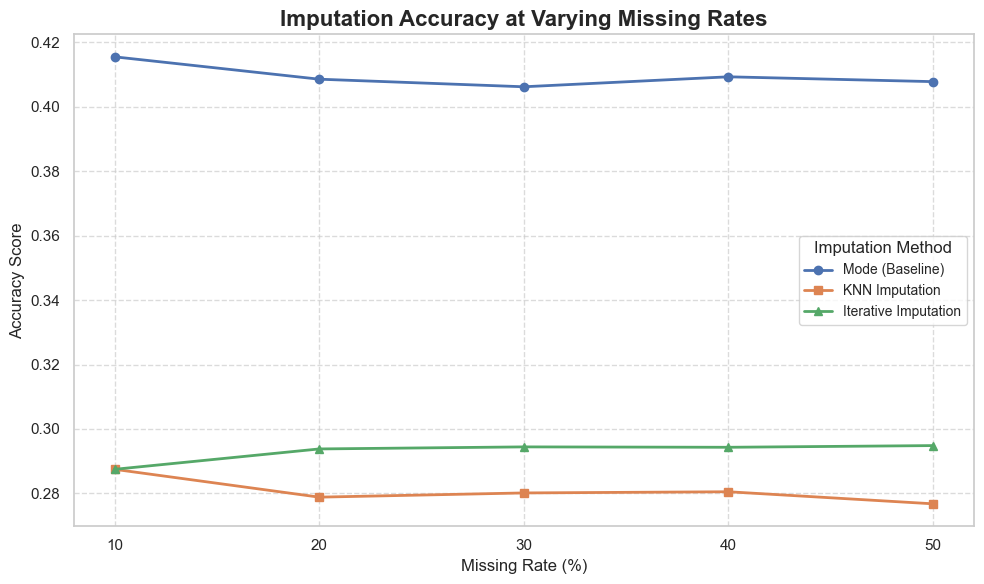

<Figure size 1500x800 with 0 Axes>

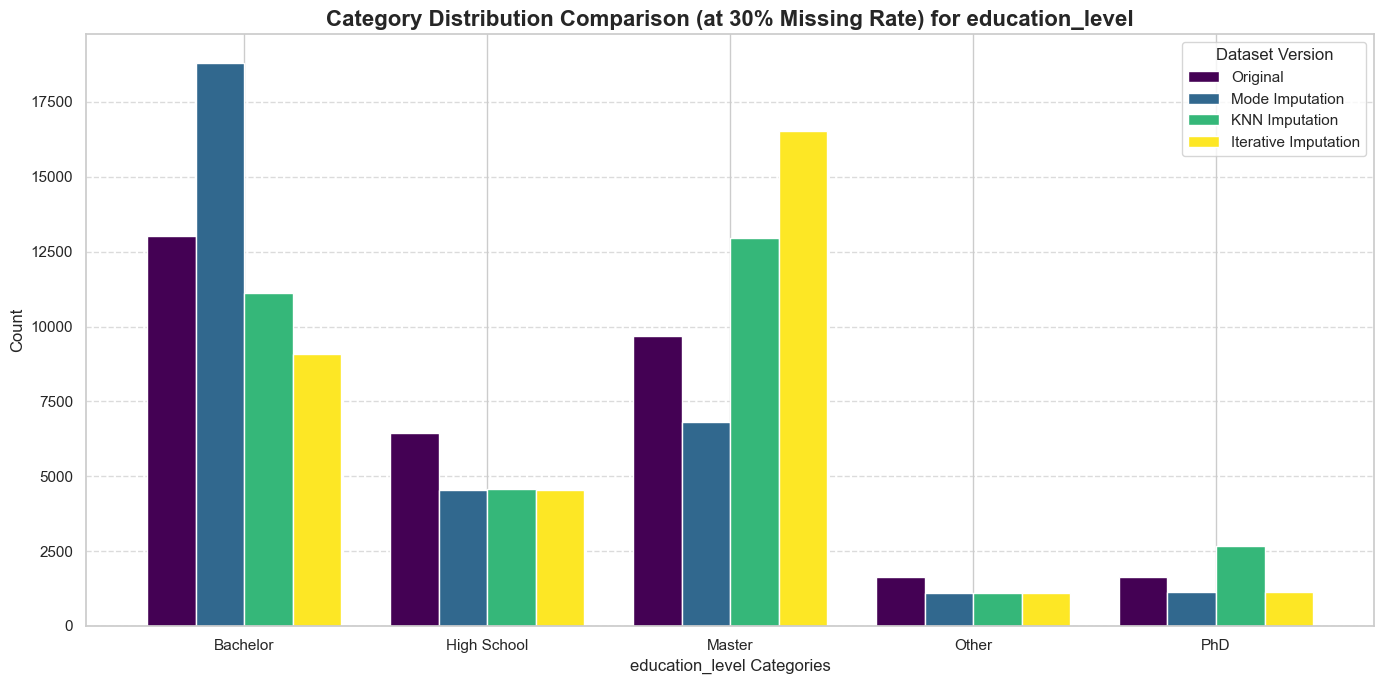


สรุปสำหรับนำไปเขียน Discussion:
1. จากกราฟแรก (Accuracy) จะเห็นความยืดหยุ่นของโมเดล Machine Learning (KNN/Iterative) เมื่อระดับ Missing Data สูงขึ้น
2. จากกราฟที่สอง (Distribution) จะแสดงให้เห็นถึงข้อจำกัดของวิธี Mode ที่มักจะทำให้ Category ที่เป็นฐานนิยมบวม (Overrepresented) ขึ้นอย่างผิดปกติ ในขณะที่วิธี ML จะกระจายการเติมค่าได้ใกล้เคียงกับ Original Distribution มากกว่า


In [5]:
# ==========================================
# ส่วนที่ 3: Results and Discussion - Visualization
# ==========================================

print("\n--- การสร้างกราฟสำหรับ Results และ Discussion ---")

# กราฟที่ 1: Performance Comparison (Accuracy vs Missing Rate)
plt.figure(figsize=(10, 6))
plt.plot(df_results['Missing_Rate'], df_results['Mode (Baseline)'], marker='o', label='Mode (Baseline)', linewidth=2)
plt.plot(df_results['Missing_Rate'], df_results['KNN Imputation'], marker='s', label='KNN Imputation', linewidth=2)
plt.plot(df_results['Missing_Rate'], df_results['Iterative Imputation'], marker='^', label='Iterative Imputation', linewidth=2)

plt.title('Imputation Accuracy at Varying Missing Rates', fontsize=16, fontweight='bold')
plt.xlabel('Missing Rate (%)', fontsize=12)
plt.ylabel('Accuracy Score', fontsize=12)
plt.xticks(df_results['Missing_Rate'])
plt.legend(title="Imputation Method", fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# กราฟที่ 2: Distribution Preservation (Discussion & Conclusion)
# แสดงว่าวิธีใดรักษาความถี่ดั้งเดิมของข้อมูล Categorical ได้ดีที่สุด (ณ Missing Rate 30%)
plt.figure(figsize=(15, 8))

# สร้างตารางนับความถี่เพื่อนำมา plot
dist_df = pd.DataFrame({
    'Original': dist_data_30_percent['Original'].value_counts(),
    'Mode Imputation': dist_data_30_percent['Mode'].value_counts(),
    'KNN Imputation': dist_data_30_percent['KNN'].value_counts(),
    'Iterative Imputation': dist_data_30_percent['Iterative'].value_counts()
}).fillna(0)

# Plot Grouped Bar Chart
dist_df.plot(kind='bar', figsize=(14, 7), width=0.8, colormap='viridis')
plt.title(f'Category Distribution Comparison (at 30% Missing Rate) for {target_col}', fontsize=16, fontweight='bold')
plt.xlabel(f'{target_col} Categories', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title="Dataset Version")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("\nสรุปสำหรับนำไปเขียน Discussion:")
print("1. จากกราฟแรก (Accuracy) จะเห็นความยืดหยุ่นของโมเดล Machine Learning (KNN/Iterative) เมื่อระดับ Missing Data สูงขึ้น")
print("2. จากกราฟที่สอง (Distribution) จะแสดงให้เห็นถึงข้อจำกัดของวิธี Mode ที่มักจะทำให้ Category ที่เป็นฐานนิยมบวม (Overrepresented) ขึ้นอย่างผิดปกติ ในขณะที่วิธี ML จะกระจายการเติมค่าได้ใกล้เคียงกับ Original Distribution มากกว่า")